# Federated Learning with `flwr`

# Inisialisasi dan Setup Project

In [1]:
!pip install -q flwr
!pip install -q "flwr-datasets[vision]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 752.9/752.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: typer
    Found existing installation: typer 0.24.1
    Uninstalling typer-0.24.1:
      Successfully uninstalled typer-0.24.1
ERROR: pip's dependency resolver

In [2]:
!flwr new @flwrlabs/quickstart-pytorch


🔗 Requesting download link for @flwrlabs/quickstart-pytorch...
🔽 Downloading ZIP into memory...
📦 Unpacking into /content/quickstart-pytorch...
🎊 Flower App creation successful.

To run your Flower App, first install its dependencies:

	cd quickstart-pytorch && pip install -e .

then, run the app:

 	flwr run .

💡 Check the README in your app directory to learn how to
customize it and how to run it using the Deployment Runtime.



In [5]:
%cd quickstart-pytorch
!pip install -e .

/content/quickstart-pytorch
Obtaining file:///content/quickstart-pytorch
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 862.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 999.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Visualisasi Persebaran Data

In [23]:
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import (
    IidPartitioner,
    DirichletPartitioner,
    ShardPartitioner,
)
from flwr_datasets.visualization import plot_label_distributions

# # Iid Partitioner
# fds = FederatedDataset(
#     dataset="uoft-cs/cifar10",
#     partitioners={
#         "train": IidPartitioner(num_partitions=10),
#     },
# )

# Dirichlet Partitioner
fds = FederatedDataset(
    dataset="uoft-cs/cifar10",
    partitioners={
        "train": DirichletPartitioner(
            num_partitions=10,
            partition_by="label",
            alpha=0.3,
            seed=42,
            min_partition_size=0,
        ),
    },
)

# # Shard Partitioner
# fds = FederatedDataset(
#     dataset="uoft-cs/cifar10",
#     partitioners={
#         "train": ShardPartitioner(
#             num_partitions=10, partition_by="label", num_shards_per_partition=2
#         ),
#     },
# )

partitioner = fds.partitioners["train"]

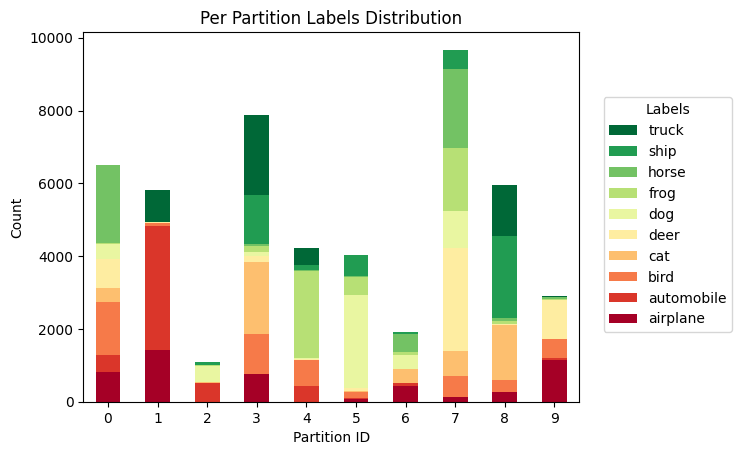

In [24]:
fig, ax, df = plot_label_distributions(
    partitioner,
    label_name="label",
    plot_type="bar",
    size_unit="absolute",
    partition_id_axis="x",
    legend=True,
    verbose_labels=True,
    title="Per Partition Labels Distribution",
)

# Training

In [9]:
!flwr run .

[Errno 2] No such file or directory: 'quickstart-pytorch'
/content/quickstart-pytorch
2026-03-04 06:40:27.029155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772606427.047255    7092 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772606427.052793    7092 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772606427.067402    7092 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772606427.067447    7092 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W

## Training dengan Parameter berbeda

In [25]:
!flwr run . --run-config "num-server-rounds=5 learning-rate=0.05"

2026-03-04 07:13:33.498128: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772608413.554696   15904 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772608413.573475   15904 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772608413.622808   15904 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772608413.622902   15904 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772608413.622908   15904 computation_placer.cc:177] computation placer alr